# scRNA-seq单细胞分析 | 复现2025年的NC文章（1） 

# 文献回顾

**前面我们讲解了于今年发表在NC上的单细胞文章，文章由希腊生物医学科学研究中心“Alexander Fleming”的研究团队专注于炎症性肠病（IBD）小鼠模型进行单细胞分析。该研究探讨了克罗恩病（Crohn’s disease, CD）样回肠炎的发病机制，重点揭示了肠道基质细胞（特别是成纤维细胞亚群）在肿瘤坏死因子（TNF）信号通路中的关键作用。使用TNF ΔARE小鼠模型（一种模拟人类CD的慢性炎症模型），研究生成了一张单细胞图谱，分析了炎症小鼠回肠中免疫细胞和基质细胞的异质性及相互作用。**
https://mp.weixin.qq.com/s/rTWG0WYu2mxDrcdd-OtTgQ

- 复现内容主要包括：在R中利用Seurat等R包进行分析 + 相关主图复现
- 复现目的主要包括：熟悉利用Seurat等R包进行单细胞分析 + 熟悉主图的绘制

# 本次复现流程
- 1.了解单细胞数据格式-使用cellranger比对和计数
- 2.双细胞预测
- 3.构建Seurat对象，质控，大类注释
- 4.提取细胞群、通过寻找锚点整合细胞群、可视化

# 比对+双细胞预测
这里作者使用cellranger count进行了10x单细胞RNA-seq数据处理，并使用scrublet机器学习算法（随机组合观察+KNN算法+自动设置阈值）来识别双细胞，来进行双细胞预测。

scrublet是一个基于单细胞RNA-seq数据的Python包，可以用来检测和过滤低质量细胞。

详细命令可以查看分享文件中的cellranger_command 和 Step1_scrublet_script 文件

最终得到的结果文件包括 炎症（TNF ΔARE）（DARE）和 健康（WT）小鼠的细胞矩阵：
- barcodes.tsv：细胞的barcode
- matrix.mtx：细胞的表达矩阵
- features.tsv：每个细胞的特征信息，包括基因名称、基因ID、染色体坐标等

以及双细胞预测的结果文件：
- scrublet_results.csv：每个细胞的scrublet分数，分数越高表示该细胞质量越好


# 使用Seurat分析scRNA-seq数据


- 初始文件
```bash
tree ../GEO_files/PROCESSED
../GEO_files/PROCESSED
├── DARE12
│   ├── barcodes.tsv.gz
│   ├── features.tsv.gz
│   └── matrix.mtx.gz
└── WT12
    ├── barcodes.tsv.gz
    ├── features.tsv.gz
    └── matrix.mtx.gz
```

## 健康小鼠WT - 创建Seurat对象并加入预测的双细胞信息


```R
library(Seurat)
# 这里我使用的Seurat版本是4.4.0（文章里使用的是v4.3.0），查看版本：packageVersion("Seurat")
library(patchwork)
library(dplyr)

#object1 initialization
obj1_counts <- Read10X("../GEO_files/PROCESSED/WT12/")
obj1 <- CreateSeuratObject(counts = obj1_counts, project = "WT12wk",
                           min.cells = 0, min.features = 0)
# 返回一个稀疏计数矩阵，其中行代表基因，列代表细胞条形码（barcode），
# 值代表该基因在该细胞中检测到的分子数（UMI计数）
obj1[["percent.mt"]] <- PercentageFeatureSet(obj1, pattern = "^mt-")
# 线粒体基因编码的RNA占比。
# 线粒体基因高表达通常指示细胞凋亡或损伤。
# 小鼠线粒体基因以"mt-"开头，人类以"MT-"开头
obj1$sample <- "wt-12w"
obj1$genotype <- "wt"
head(obj1@meta.data)

#doublet removal
#load scrublet results
# 双细胞问题：​​ 使用scrublet算法detect doublets，并将结果导入Seurat对象
obj1_doublets <- read.csv("../Step1_DoubletRemovalWithScrublet/WT12_scrublet_results.csv")
colnames(obj1_doublets)[1] <- "Cell_id"
obj1_doublets <- obj1_doublets[, c("Cell_id", "predicted_doublets")]

metadata_temp1 <- as.data.frame(obj1@meta.data)
metadata_temp1$Cell_id <- rownames(metadata_temp1)
metadata_temp1 <- left_join(metadata_temp1, obj1_doublets)
rownames(metadata_temp1) <- metadata_temp1$Cell_id

obj1@meta.data <- metadata_temp1
Idents(obj1) <- obj1$predicted_doublets

#View QC plots before doublet removal
VlnPlot(obj1, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
        ncol = 3, group.by = "orig.ident", pt.size = 0)

# 三个关键质控指标：​​
# ​nFeature_RNA​：每个细胞检测到的基因数
# ​nCount_RNA​：每个细胞的总UMI计数（转录本数）
# ​percent.mt​：线粒体基因占比
# 质控阈值判断标准
# 
# ​nFeature_RNA过低​：可能为空液滴或死细胞
# ​nFeature_RNA过高​：可能为多个细胞形成的双细胞
# ​percent.mt过高​：通常>5-10%表示细胞状态不佳

#Remove doublets
obj1_no_doublets <- subset(obj1, idents = "False")

obj1 #43119 cells
obj1_no_doublets #35887 cells

#View QC plots after doublet removal
VlnPlot(obj1_no_doublets, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3, group.by = "orig.ident", pt.size = 0)
saveRDS(obj1_no_doublets, "../output/wt12_no_doubletsDefaultThreshold_not_filtered.RDS")

```

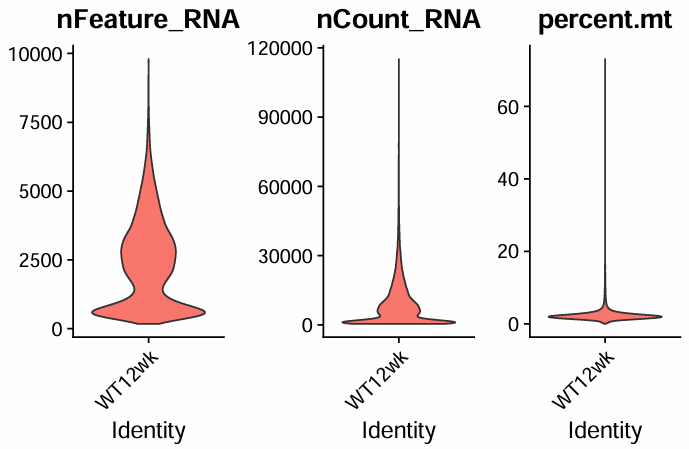

## 炎症小鼠DARE - 创建Seurat对象创建Series对象
  


```R
# 流程跟处理健康小鼠数据一样，只是数据集换成了DARE12数据集。
obj2_counts <- Read10X("../GEO_files/PROCESSED/DARE12/")
......略......

obj2_doublets <- read.csv("../Step1_DoubletRemovalWithScrublet/DARE12_scrublet_results.csv")
......略......

saveRDS(obj2_no_doublets, "../output/dare12_no_doubletsDefaultThreshold_not_filtered.RDS")
......略......
```

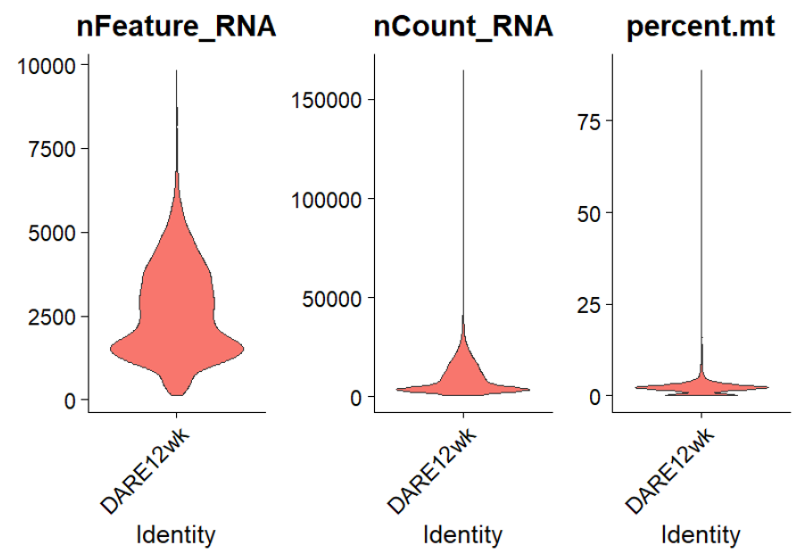


# Seurat分析流程

## 健康小鼠的单细胞的Seurat对象分析
- 1. 去除低质量细胞和双细胞
- 2. 标准化：消除细胞间测序深度的技术差异
- 3. 识别高变基因
- 4. 标准化基因表达量，消除技术变异的影响
- 5. 降维、聚类、可视化分析

- 质控
```R
rm(list=ls())
library(Seurat)
library(ggplot2)
# remotes::install_github("samuel-marsh/scCustomize@v1.1.3")
library(scCustomize)

#load object
obj <- readRDS("../Step2_InitialSeuratObjects/wt12_no_doubletsDefaultThreshold_not_filtered.RDS")

#QC filtering
VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"))

obj_filtered <- subset(obj, subset = nFeature_RNA > 800 & 
                         nFeature_RNA < 7500 & percent.mt < 5)
# nFeature_RNA > 800​：确保细胞有足够的基因表达信息
# ​nFeature_RNA < 7500​：排除可能的多细胞或双细胞
# ​percent.mt < 5​：排除线粒体基因污染严重的低质量细胞
VlnPlot(obj_filtered, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"))
```

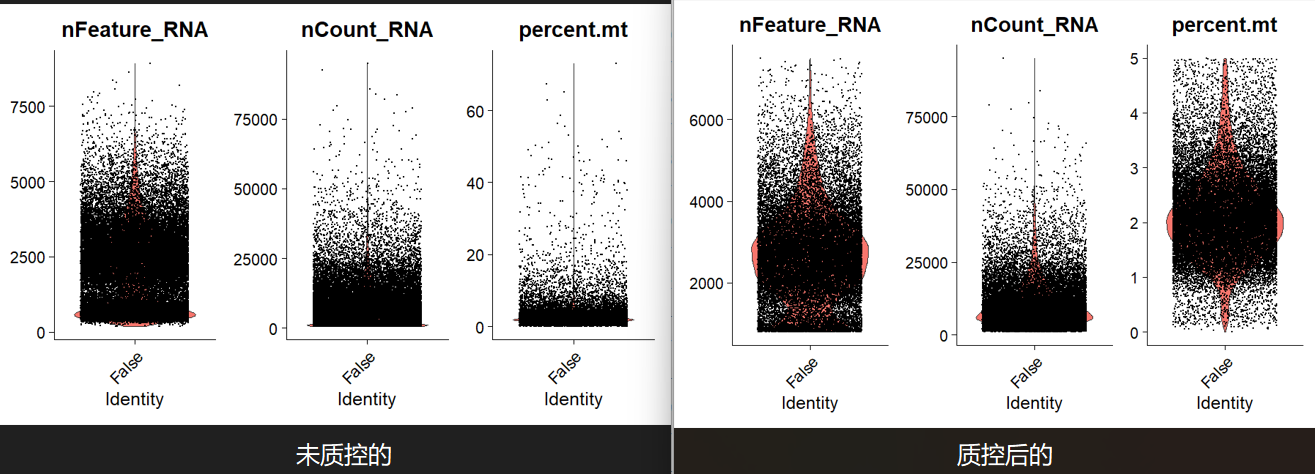

- 标准化
```R
#normalization
obj_filtered <- NormalizeData(obj_filtered)
# 作用​：消除细胞间测序深度的技术差异。
# ​原理​：默认使用"LogNormalize"方法，将每个细胞的基因表达量除以该细胞的总UMI数，乘以缩放因子10,000，然后进行对数转换
# 。这使得不同细胞间的表达量具有可比性。

#HVGs
obj_filtered <- FindVariableFeatures(obj_filtered, selection.method = "mvp")
# 作用​：识别在细胞间表达变异最大的基因，用于下游分析。
# ​原理​：高变基因通常包含区分不同细胞类型的生物信号，
# 聚焦这些基因可以提高分析效率和准确性。
# "mvp"方法基于平均表达量和离散度来选择基因

# Identify the 10 most highly variable genes
top10 <- head(VariableFeatures(obj_filtered), 10)

# plot variable features with and without labels
plot1 <- VariableFeaturePlot(obj_filtered)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot1 + plot2
# 图略

#scaling
#all.genes <- rownames(obj_filtered)
obj_filtered <- ScaleData(obj_filtered, vars.to.regress = c("nCount_RNA", "percent.mt"))
# 作用​：标准化基因表达量，消除技术变异的影响。
# ​原理​：
# 将每个基因的表达量转换为z-score（均值为0，方差为1）
# vars.to.regress参数回归去除nCount_RNA和percent.mt的影响，
# 减少测序深度和线粒体污染带来的技术偏差
# 为PCA分析做准备，确保高表达基因不会主导分析结果

#PCA
obj_filtered <- RunPCA(obj_filtered, features = VariableFeatures(object = obj_filtered))
ElbowPlot(obj_filtered, ndims = 50)

#Clustering
obj_filtered <- FindNeighbors(obj_filtered, dims = 1:20)
obj_filtered <- FindClusters(obj_filtered, resolution = 0.01)
# FindNeighbors：基于PCA空间构建K近邻图，连接相似的细胞
# FindClusters：应用Louvain算法识别细胞群落，resolution参数控制聚类粒度（值越小聚类越少）

#UMAP
obj_filtered <- RunUMAP(obj_filtered, dims = 1:20)
DimPlot(obj_filtered, reduction = "umap", label = T)
# 作用​：非线性降维可视化，保留细胞间的全局和局部结构关系。
# ​原理​：UMAP比t-SNE能更好地保留数据的全局结构，用于直观展示细胞亚群的分布

#annotation of WT
new.cluster.ids <- c("Lymphoid", "Stroma", "Lymphoid", "Myeloid", "Stroma", "Stroma")
names(new.cluster.ids) <- levels(obj_filtered)
obj_filtered <- RenameIdents(obj_filtered, new.cluster.ids)
# 作用​：基于已知的标记基因将聚类结果转换为有生物学意义的细胞类型。
# ​注释依据​：
# ​Lymphoid​：免疫细胞谱系（如T细胞、B细胞）
# ​Myeloid​：髓系免疫细胞（如巨噬细胞、树突状细胞）
# ​Stroma​：基质细胞（如成纤维细胞
#save
saveRDS(obj_filtered, "WT12_weeks_before_integration_nF_800.RDS") 

#used in Fig1b
FeaturePlot(obj_filtered, features = "Itgax", order = T, label = T, cols = c("grey70", "red"))
FeaturePlot(obj_filtered, features = "Itgam", order = T, label = T, cols = c("grey70", "red"))
FeaturePlot(obj_filtered, features = "Ptprc", order = T, label = T, cols = c("grey70", "red"))
FeaturePlot(obj_filtered, features = "Col1a1", order = T, label = T, cols = c("grey70", "red"))
# 验证
# Itgax​（CD11c）：树突状细胞标记
# ​Itgam​（CD11b）：髓系细胞标记
# ​Ptprc​（CD45）：白细胞共同标记
# ​Col1a1​：胶原蛋白，基质细胞标记
```
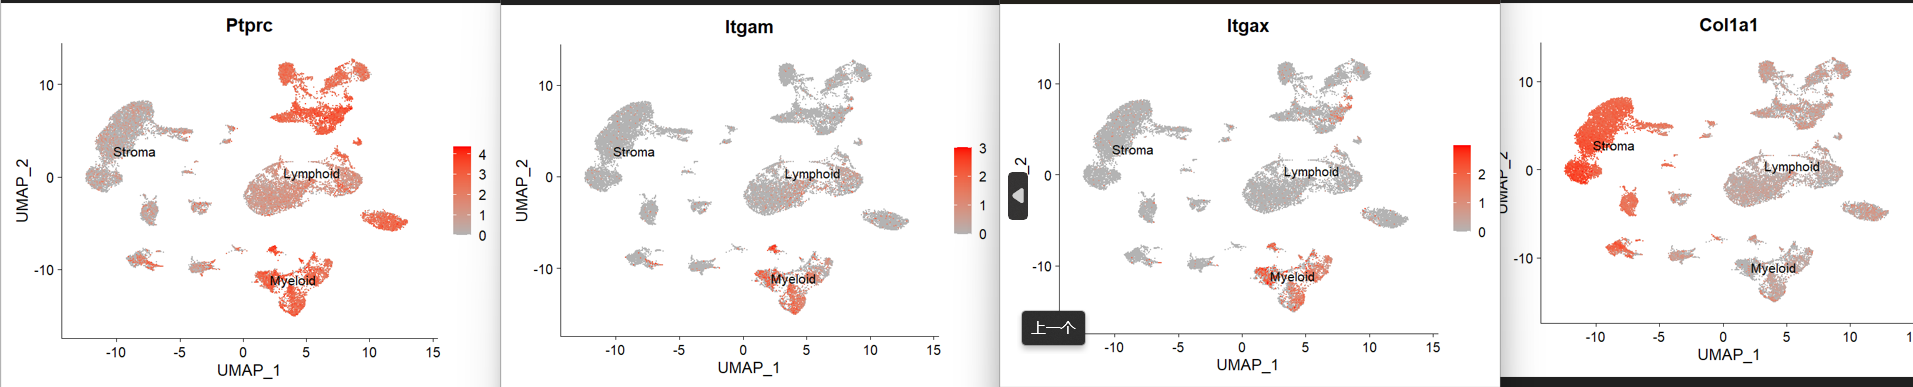


```R
DimPlot_scCustom(obj_filtered, colors_use = c("purple", "coral", "grey"), pt.size = 0.8, label.size = 7) + 
  theme(axis.line = element_blank(), 
        axis.text = element_blank(), 
        axis.ticks = element_blank(),
        axis.title = element_blank()
        )

#  分析流程总结
# 这个流程体现了单细胞分析的标准范式：
# 质控过滤→标准化→特征选择→降维聚类→细胞注释
# 每个步骤都为后续分析奠定基础，确保结果的生物学可靠性
# 这种分析能够揭示细胞异质性，识别稀有细胞类型，
# 为理解组织微环境的细胞组成和功能状态提供重要见解。

# Q:高变基因识别之前不对数据进行缩放和批次效应矫正
# 数据标准化在高变基因识别之前；
# 消除细胞间测序深度的技术差异，使表达量可比。为准确评估基因变异提供公平的“起跑线”。
# 而数据缩放和批次效应矫正在后：避免对高变基因选择引入偏差。
# 将基因表达值转换为Z-score，为线性降维（如PCA）做准备。

```
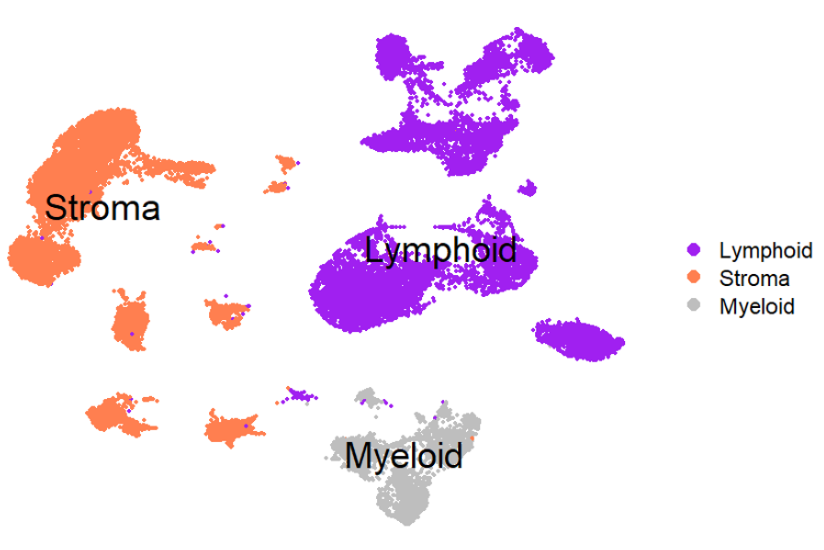

## 炎症小鼠的单细胞Seurat对象分析


```R
# 相关代码和处理健康小鼠数据的流程相同，这里不再赘述。
obj <- readRDS("../Step2_InitialSeuratObjects/dare12_no_doubletsDefaultThreshold_not_filtered.RDS")
......略......
obj_filtered <- FindNeighbors(obj_filtered, dims = 1:22)
obj_filtered <- FindClusters(obj_filtered, resolution = 0.01)
......略......
#UMAP
obj_filtered <- RunUMAP(obj_filtered, dims = 1:22)
......略......
saveRDS(obj_filtered, "DARE12_weeks_before_integration_nF_800.RDS")

......略......
DimPlot_scCustom(obj_filtered, colors_use = c("purple", "grey", "coral"), pt.size = 0.8, label.size = 7) + 
  theme(axis.line = element_blank(), 
        axis.text = element_blank(), 
        axis.ticks = element_blank(),
        axis.title = element_blank()
  )

```
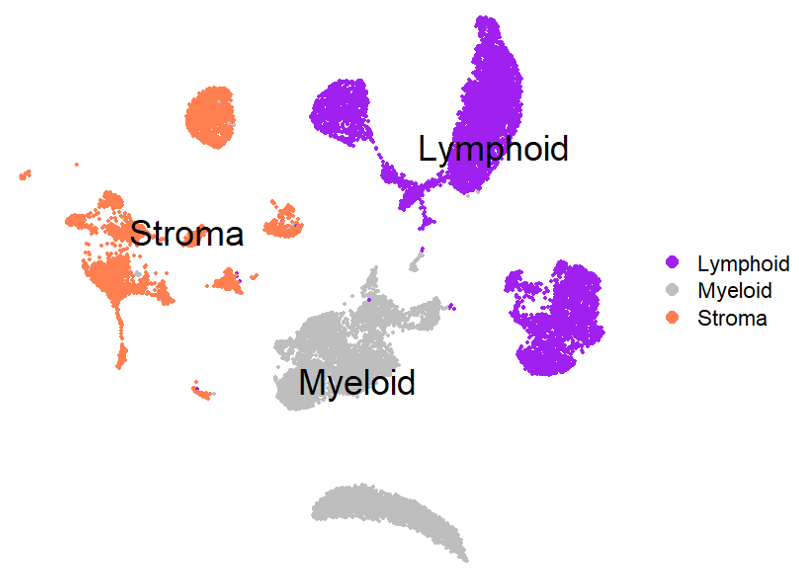

# 对​Lymphoid​：免疫细胞谱系、​Myeloid​：髓系免疫细胞、​Stroma​：基质细胞提取分开分析
- 作者在构建回肠单细胞图谱时主动排除上皮细胞（Epcam⁺）。因为研究目标是为了证明 成纤维细胞（而非上皮）是 TNF 信号的主要响应者并协调免疫细胞募集。所以后续分析主要是将所有细胞分为​Lymphoid​：免疫细胞谱系、​Myeloid​：髓系免疫细胞、​Stroma​：基质细胞三大类。然后进行细致的分析和机制的探索。



## 从完整的Seurat对象中，根据细胞身份（idents）提取出指定大类（如 "Myeloid"）的所有细胞，创建一个新的、只包含该大类细胞的Seurat对象

```R
rm(list=ls())
library(Seurat)

wt12 <- readRDS("../Step3_SeuratWorkflowPerSample/WT12_weeks_before_integration_nF_800.RDS")
dare12 <- readRDS("../Step3_SeuratWorkflowPerSample/DARE12_weeks_before_integration_nF_800.RDS")

analyzeAndSaveObjects <- function(seu_obj, supercluster, nPCs, resolution, sampleName)
{
  obj_filtered <- subset(seu_obj, idents = supercluster)
  # 从完整的Seurat对象中，根据细胞身份（idents）提取出指定大类（如 "Myeloid"）的所有细胞，
  # 创建一个新的、只包含该大类细胞的Seurat对象
  
  #normalization
  obj_filtered <- NormalizeData(obj_filtered)
  
  #HVGs
  obj_filtered <- FindVariableFeatures(obj_filtered, selection.method = "mvp")
  
  # Identify the 10 most highly variable genes
  top10 <- head(VariableFeatures(obj_filtered), 10)
  
  # plot variable features with and without labels
  plot1 <- VariableFeaturePlot(obj_filtered)
  plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
  p1 <- plot1 + plot2
  ggsave(plot = p1, filename = paste0("s4.", sampleName, "_", supercluster, ".VariableFeaturePlot.png"),
                                      width = 12, height = 6, dpi = 300)
  
  #scaling
  #all.genes <- rownames(obj_filtered)
  obj_filtered <- ScaleData(obj_filtered, vars.to.regress = c("nCount_RNA", "percent.mt"))
  
  #PCA
  obj_filtered <- RunPCA(obj_filtered, features = VariableFeatures(object = obj_filtered))
  p2 <- ElbowPlot(obj_filtered, ndims = 50)
  ggsave(plot = p2, filename = paste0("s4.", sampleName, "_", supercluster, ".ElbowPlot.png"),
         width = 10, height = 6, dpi = 300)
  
  #Clustering
  obj_filtered <- FindNeighbors(obj_filtered, dims = 1:nPCs)
  obj_filtered <- FindClusters(obj_filtered, resolution = resolution)
  
  #UMAP
  obj_filtered <- RunUMAP(obj_filtered, dims = 1:nPCs)
  obj_filtered <- RunTSNE(obj_filtered, dims = 1:nPCs)
  p3 <- DimPlot(obj_filtered, reduction = "umap")
  ggsave(plot = p3, filename = paste0("s4.", sampleName, "_", supercluster, ".DimPlot.png"),
         width = 6, height = 6, dpi = 300)
  
  #export RDS
  saveRDS(object = obj_filtered, file = paste0(sampleName, "_", supercluster, "_PCs_", nPCs, "_", resolution, ".RDS")) 
}

analyzeAndSaveObjects(seu_obj = wt12, supercluster = "Myeloid", 
                      nPCs = 14, resolution = 0.5, sampleName = "wt12")
analyzeAndSaveObjects(seu_obj = dare12, supercluster = "Myeloid", 
                      nPCs = 21, resolution = 0.5, sampleName = "dare12")

analyzeAndSaveObjects(seu_obj = wt12, supercluster = "Lymphoid", 
                      nPCs = 15, resolution = 0.5, sampleName = "wt12")
analyzeAndSaveObjects(seu_obj = dare12, supercluster = "Lymphoid", 
                      nPCs = 23, resolution = 0.5, sampleName = "dare12")

analyzeAndSaveObjects(seu_obj = wt12, supercluster = "Stroma", 
                      nPCs = 20, resolution = 0.5, sampleName = "wt12")
analyzeAndSaveObjects(seu_obj = dare12, supercluster = "Stroma", 
                      nPCs = 22, resolution = 0.5, sampleName = "dare12")

```
**得到三大细胞群的Seurat对象，分别为WT12、DARE12的Myeloid、Lymphoid、Stroma。**


## 后续分析：（详细见代码分析）
- 1. 随后进一步通过DoubletFinder算法分别对三大细胞群进行质控
- 2，然后通过FindIntegrationAnchors函数寻找WT12、DARE12两个数据集中那些处于相同生物学状态的细胞对（即“锚点”）进行整合。
- 3. 对进行整合的Myeloid、Lymphoid、Stroma三大细胞群进行注释

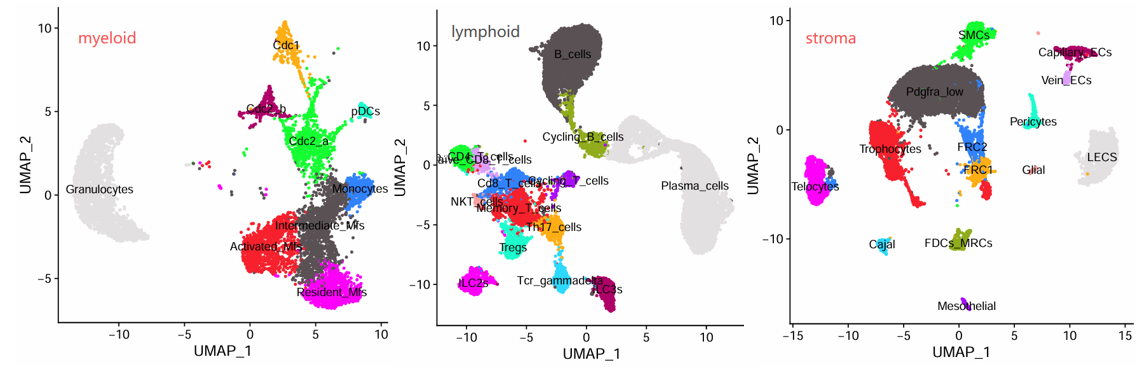